In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!cp -r /content/drive/MyDrive/dataset /content/local_dataset

In [ ]:
# Notebook implementing the DenseNet121 module for further use on the Pet's
# Facial Expression Image dataset
# Implemented module will be built using Pytorch and Keras only
import torch
import tensorflow as tf
import keras as k
from keras.layers import *
from keras.models import Model
import sklearn
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [11]:
# Batch Normalization, ReLU, and Convolution
def batch_norm_relu_conv(x, filters, kernel=1, strides=1):
  x = BatchNormalization(axis=-1)(x)
  x = Activation('relu')(x)
  x = Conv2D(filters, kernel, strides=strides, padding='same', use_bias=False)(x)
  return x

# Dense Layer with adjustable number of repetitions
def dense_layer(x, filter, repetitions):
  for _ in range(repetitions):
    y = batch_norm_relu_conv(x, 4 * filter)
    y = batch_norm_relu_conv(y,filter, 3)
    x = concatenate([y, x], axis=-1)
  return x

# Transition layers:
def transition_layer(x):
  num_filters =x.shape[-1] // 2
  x = batch_norm_relu_conv(x, num_filters)
  x = AveragePooling2D((2, 2), strides=(2, 2), padding='same')(x)
  return x

In [ ]:
# Input image 224 x 224 x 3
input_img = Input(shape=(224, 224, 3))
x = Conv2D(64, (7, 7), strides=(2, 2), padding='same', use_bias=False)(input_img)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
repetitions_list = [6, 12, 24, 16]
for i, repetition in enumerate(repetitions_list):
  d = dense_layer(x, 32, repetition)
  if i != len(repetitions_list) - 1:
    x = transition_layer(x)

x = BatchNormalization(axis=-1)(x)
x = Activation('relu')(x)
x = GlobalAveragePooling2D()(x)
# Adding dropout to prevent overfitting, especially since the dataset may be small and the model is complex.
x = Dropout(0.5)(x)
num_classes = 4
predictions = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=input_img, outputs=predictions, name='densenet121')
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
model.summary()

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_120 (Conv2D)             │ (None, 112, 112, 64)   │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_121         │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_121 (Activation)     │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_134         │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_134 (Activation)     │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_133 (Conv2D)             │ (None, 56, 56, 32)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 28, 28, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_159         │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_159 (Activation)     │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_158 (Conv2D)             │ (None, 28, 28, 16)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 14, 14, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_208         │ (None, 14, 14, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_208 (Activation)     │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_207 (Conv2D)             │ (None, 14, 14, 8)      │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 7, 7, 8)        │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_241         │ (None, 7, 7, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_241 (Activation)     │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 12,868 (50.27 KB)

 Trainable params: 12,500 (48.83 KB)

 Non-trainable params: 368 (1.44 KB)

In [13]:
# Data processing and augmentation
# Loading the dataset
training_data_dir = '/content/local_dataset/train'
validation_data_dir = '/content/local_dataset/valid'
testing_data_dir = '/content/local_dataset/test'

# The training samples will be the only ones augmented, not the valaidation and test
train_data_generation = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')
# No augmentation
# train_data_generation = ImageDataGenerator(rescale=1./255)

# Only rescaling
validation_data_generation = ImageDataGenerator(rescale=1./255)
test_data_generation = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = train_data_generation.flow_from_directory(training_data_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical')
validation_generator = validation_data_generation.flow_from_directory(validation_data_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical', shuffle=False)
test_generator = test_data_generation.flow_from_directory(testing_data_dir, target_size=(224, 224), batch_size=batch_size, class_mode='categorical', shuffle=False)


Found 1000 images belonging to 4 classes.
Found 36 images belonging to 4 classes.
Found 38 images belonging to 4 classes.


In [ ]:
# Training the model
# Adding a learning rate scheduler to reduce the learning rate when the validation loss plateaus, which can help improve the model's performance and convergence.
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
# Adding early stopping to prevent overfitting by monitoring the validation loss and stopping training when it stops improving for a certain number of epochs.
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
history = model.fit(train_generator, epochs=25, validation_data=validation_generator,
          callbacks=[lr_scheduler, early_stopping])

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 601ms/step - accuracy: 0.2660 - loss: 1.5070 - precision_1: 0.2746 - recall_1: 0.0390 - val_accuracy: 0.3056 - val_loss: 1.3856 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 353ms/step - accuracy: 0.3100 - loss: 1.4130 - precision_1: 0.4884 - recall_1: 0.0210 - val_accuracy: 0.2778 - val_loss: 1.3971 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 396ms/step - accuracy: 0.3110 - loss: 1.3750 - precision_1: 0.6552 - recall_1: 0.0190 - val_accuracy: 0.2778 - val_loss: 1.3951 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 404ms/step - accuracy: 0.3240 - loss: 1.3574 - precision_1: 0.6333 - recall_1: 0.0190 - val_accuracy: 0.2778 - val_loss: 1.4093 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 422ms/step - accuracy: 0.3410 - loss: 1.3454 - pre

Evaluating model on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step


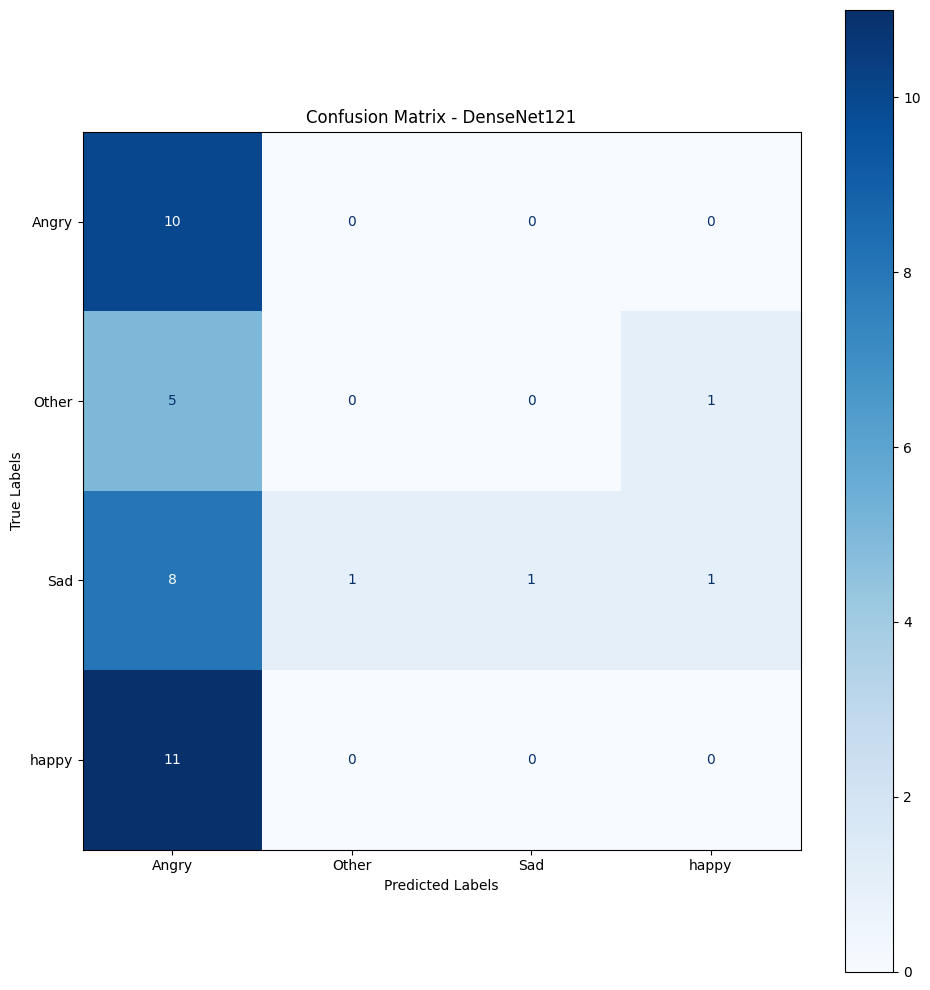

Classification Report:
              precision    recall  f1-score   support

           0       0.29      1.00      0.45        10
           1       0.00      0.00      0.00         6
           2       1.00      0.09      0.17        11
           3       0.00      0.00      0.00        11

    accuracy                           0.29        38
   macro avg       0.32      0.27      0.16        38
weighted avg       0.37      0.29      0.17        38



In [15]:
# Evaluate on test set
print('Evaluating model on test set...')
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_predicted = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_predicted)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
figure, ax = plt.subplots(figsize=(10, 10))
display_cm.plot(ax=ax, cmap='Blues', colorbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
ax.set_title('Confusion Matrix - DenseNet121')
plt.tight_layout()
plt.show()

# Classification report

print("Classification Report:")
print(classification_report(y_true, y_predicted))